In [1]:
# 📌 Cell 1: Imports
import os
import json
import numpy as np
import pickle
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Masking
from tensorflow.keras.utils import to_categorical


In [2]:
# 📌 Cell 2: Preprocessor Class
class Preprocessor:
    def __init__(self, seq_len=50, n_hand=21, n_pose=33):
        self.SEQ_LEN = seq_len
        self.N_HAND = n_hand
        self.N_POSE = n_pose
        self.FEAT_PER_FRAME = (self.N_HAND*3) + (self.N_HAND*3) + (self.N_POSE*3)  # L + R + Pose

    def _to_xyz_array(self, items, expected_len):
        out = np.zeros((expected_len, 3), dtype=np.float32)
        if not isinstance(items, (list, tuple)) or len(items) == 0:
            return out
        m = min(len(items), expected_len)
        for i in range(m):
            lm = items[i] or {}
            try:
                out[i, 0] = float(lm.get('x', 0.0))
                out[i, 1] = float(lm.get('y', 0.0))
                out[i, 2] = float(lm.get('z', 0.0))
            except Exception:
                out[i] = 0.0
        return out

    def _vectorize_frame(self, frame):
        left  = self._to_xyz_array(frame.get('left', []),  self.N_HAND)
        right = self._to_xyz_array(frame.get('right', []), self.N_HAND)
        pose  = self._to_xyz_array(frame.get('pose', []),  self.N_POSE)

        l_sh, r_sh = pose[11], pose[12]
        has_shoulders = (np.any(l_sh) and np.any(r_sh))
        if has_shoulders:
            center = (l_sh + r_sh) / 2.0
            scale = np.linalg.norm(l_sh[:2] - r_sh[:2])
            if scale < 1e-6:
                scale = 1.0
        else:
            center = pose[0] if np.any(pose[0]) else np.zeros(3, dtype=np.float32)
            scale = 1.0

        def norm(arr):
            arr = arr - center
            arr = arr / scale
            return arr

        left  = norm(left)
        right = norm(right)
        pose  = norm(pose)

        feat = np.concatenate([left.flatten(), right.flatten(), pose.flatten()], axis=0)
        return feat.astype(np.float32)

    def preprocess_sequence(self, seq):
        frames = seq if isinstance(seq, (list, tuple)) else []
        if len(frames) == 0:
            frames = [{}]

        if len(frames) > self.SEQ_LEN:
            frames = frames[-self.SEQ_LEN:]
        if len(frames) < self.SEQ_LEN:
            pad_count = self.SEQ_LEN - len(frames)
            frames = ([{'left': [], 'right': [], 'pose': []}] * pad_count) + frames

        feats = np.stack([self._vectorize_frame(f) for f in frames], axis=0)
        return feats  # (SEQ_LEN, FEAT_PER_FRAME)

def load_sequence_from_json_obj(obj):
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        for key in ['sequence', 'frames', 'data']:
            if key in obj and isinstance(obj[key], list):
                return obj[key]
    if isinstance(obj, dict) and all(k in obj for k in ['left', 'right', 'pose']):
        return [obj]
    return []


In [3]:
# 📌 Cell 3: Configurations
DATASET_DIR = "dataset"  # dataset/<label>/<sample>.json
SEQ_LEN = 50
N_HAND = 21
N_POSE = 33
BATCH_SIZE = 16
EPOCHS = 40
MODEL_DIR = "artifacts"
os.makedirs(MODEL_DIR, exist_ok=True)

prep = Preprocessor(seq_len=SEQ_LEN, n_hand=N_HAND, n_pose=N_POSE)


In [4]:
# 📌 Cell 4: Dataset Discovery and Loading
def discover_dataset(data_dir):
    labels = sorted([d.name for d in Path(data_dir).iterdir() if d.is_dir()])
    if not labels:
        raise RuntimeError("❌ No label folders found in dataset/")

    X, y = [], []
    for lbl in labels:
        lbl_dir = Path(data_dir) / lbl
        for p in lbl_dir.glob("*.json"):
            try:
                with open(p, "r", encoding="utf-8") as f:
                    obj = json.load(f)
                seq = load_sequence_from_json_obj(obj)
                feats = prep.preprocess_sequence(seq)
                if feats.shape != (SEQ_LEN, prep.FEAT_PER_FRAME):
                    continue
                X.append(feats)
                y.append(lbl)
            except Exception as e:
                print(f"⚠️ Skipping {p} due to error: {e}")

    if not X:
        raise RuntimeError("❌ No valid samples loaded. Check dataset format.")

    X = np.stack(X, axis=0).astype(np.float32)
    y = np.array(y)
    return X, y, labels

# Load dataset
X, y, labels = discover_dataset(DATASET_DIR)
print(f"✅ Loaded {len(X)} samples across {len(labels)} classes.")
print(f"Input shape: {X.shape}")


✅ Loaded 2500 samples across 51 classes.
Input shape: (2500, 50, 225)


In [6]:
# 📌 Cell 5: Label Encoding and Train-Test Split
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded, num_classes=len(le.classes_))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y_cat, random_state=42
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (2000, 50, 225), Test shape: (500, 50, 225)


In [7]:
# 📌 Cell 6: Model Definition
def build_model(input_shape, num_classes):
    model = Sequential([
        Masking(mask_value=0.0, input_shape=input_shape),
        Bidirectional(LSTM(256, return_sequences=True)),
        Dropout(0.4),
        Bidirectional(LSTM(128)),
        Dropout(0.4),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

model = build_model((SEQ_LEN, prep.FEAT_PER_FRAME), len(le.classes_))
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 masking (Masking)           (None, 50, 225)           0         
                                                                 
 bidirectional (Bidirectiona  (None, 50, 512)          987136    
 l)                                                              
                                                                 
 dropout (Dropout)           (None, 50, 512)           0         
                                                                 
 bidirectional_1 (Bidirectio  (None, 256)              656384    
 nal)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense (Dense)               (None, 128)               3

In [8]:
# 📌 Cell 7: Training
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/40
125/125 [==============================] - 53s 367ms/step - loss: 3.2008 - accuracy: 0.1385 - val_loss: 2.2081 - val_accuracy: 0.3400
Epoch 2/40
125/125 [==============================] - 32s 252ms/step - loss: 2.1339 - accuracy: 0.3615 - val_loss: 1.4193 - val_accuracy: 0.5780
Epoch 3/40
125/125 [==============================] - 25s 202ms/step - loss: 1.6109 - accuracy: 0.4885 - val_loss: 1.1480 - val_accuracy: 0.6400
Epoch 4/40
125/125 [==============================] - 25s 203ms/step - loss: 1.2284 - accuracy: 0.5970 - val_loss: 0.7733 - val_accuracy: 0.7480
Epoch 5/40
125/125 [==============================] - 25s 202ms/step - loss: 0.9986 - accuracy: 0.6650 - val_loss: 0.6002 - val_accuracy: 0.7680
Epoch 6/40
125/125 [==============================] - 25s 203ms/step - loss: 0.8114 - accuracy: 0.7230 - val_loss: 0.6482 - val_accuracy: 0.8020
Epoch 7/40
125/125 [==============================] - 25s 203ms/step - loss: 0.7883 - accuracy: 0.7495 - val_loss: 0.5342 - val_ac

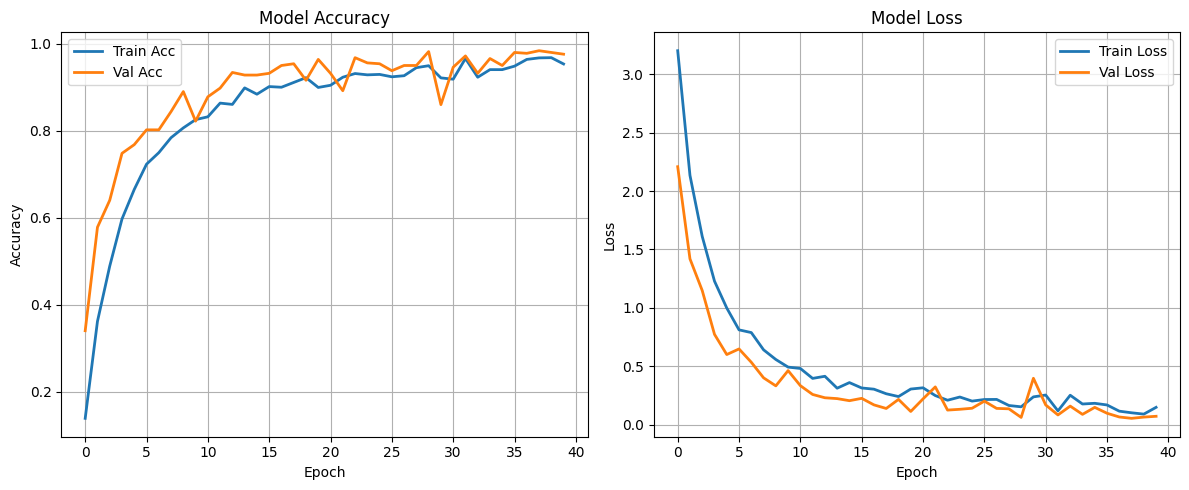

In [9]:
# 📌 Cell 8: Plot Training Curves
def plot_training(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Val Acc', linewidth=2)
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_training(history)


In [10]:
# 📌 Cell 9: Save Model and Artifacts
model_path = os.path.join(MODEL_DIR, "sign_model.h5")
label_path = os.path.join(MODEL_DIR, "label_encoder.pkl")
config_path = os.path.join(MODEL_DIR, "config.json")

model.save(model_path)
with open(label_path, "wb") as f:
    pickle.dump(le, f)

with open(config_path, "w", encoding="utf-8") as f:
    json.dump({
        "SEQ_LEN": SEQ_LEN,
        "N_HAND": N_HAND,
        "N_POSE": N_POSE,
        "FEAT_PER_FRAME": prep.FEAT_PER_FRAME,
        "CLASSES": le.classes_.tolist()
    }, f, indent=2)

print("✅ Training complete and artifacts saved.")
print(f"📦 Model saved: {model_path}")
print(f"🧠 Labels saved: {label_path}")
print(f"⚙️ Config saved: {config_path}")


✅ Training complete and artifacts saved.
📦 Model saved: artifacts\sign_model.h5
🧠 Labels saved: artifacts\label_encoder.pkl
⚙️ Config saved: artifacts\config.json
